# Detección de fuego y humo con grilla 4×4

**Proyecto Final de Ingeniería en Electrónica — FaCENA-UNNE**
(Red de sensores LoRa para detección temprana de incendios)

Variante de `4.red_entrenada.ipynb`: misma red base (MobileNetV1 α=0.25, 96×96 RGB), mismo
banco (D-Fire, partición oficial) y mismo régimen de entrenamiento. Cambia **qué se le
pide a la red**:

| Salida | Forma | Qué mide |
|---|---|---|
| `salida` | 2 | P(`fuego`), P(`humo`) en la imagen — igual que el notebook 4 |
| `grilla` | 4×4×2 | P(`fuego`), P(`humo`) en cada celda de 24×24 px |

La grilla se entrena con las **cajas YOLO** del banco, que el notebook 4 descarta (de cada
caja sólo usa la clase). Con una etiqueta por imagen la red tiene que descubrir sola
*dónde* está el fuego, y puede acertar mirando otra cosa (un cielo naranja, un
atardecer). Con una etiqueta por celda se le dice dónde está, y se la corrige cuando mira
el lugar equivocado.

Dos preguntas, un solo entrenamiento:

1. **¿La supervisión por celda mejora al clasificador?** La cabeza `salida` es la del
   notebook 4, así que sus métricas se comparan directamente con las de allá (§6).
   Si mejora, sirve aunque la grilla nunca llegue al nodo.
2. **¿Cuánto vale la grilla como salida del nodo?** 16 celdas × 2 bits = 4 bytes por
   LoRa: dice *dónde* está el fuego en el cuadro, no sólo *si* hay. Encaja con la grilla
   0…15 de los datos 2D del concepto del proyecto.

Qué cambia respecto del notebook 4:

- **§2 Etiquetas por celda.** Cada caja se pinta en una máscara de 96×96 y una celda vale
  1 si tiene al menos un píxel de caja.
- **§3 Aumento en el pipeline, no en el modelo.** Rotar o hacer zoom mueve el fuego de
  celda: la máscara tiene que transformarse junto con la imagen, y el modelo no ve las
  etiquetas. El aumento pasa a `tf.data`.
- **§4 Segunda cabeza** sobre el mapa de 12×12 de MobileNet: +2,1 k parámetros y +34 k MAC
  (0,45 % del total).
- **§5 Pérdida doble**: la de imagen + λ · la de grilla, con más peso en las celdas
  positivas.
- **§6–7 Evaluación de la grilla** en lugar de Grad-CAM: la grilla ya es un mapa de dónde
  ve fuego la red, y se puede medir contra las cajas.

La cuantización de este modelo todavía no está hecha: `5_cuantizacion.ipynb` espera una
sola salida de 2 valores. Por eso este notebook guarda el modelo con otro nombre, para que
el 5 no lo tome por error (§8).

## 0. Descarga del dataset

Descargamos **D-Fire** en formato YOLO (bounding boxes para humo y fuego) desde
Kaggle: [`sayedgamal99/smoke-fire-detection-yolo`](https://www.kaggle.com/datasets/sayedgamal99/smoke-fire-detection-yolo).
Con `KAGGLEHUB_CACHE` apuntando a `data/` del proyecto, el dataset queda dentro del
proyecto (no en `~/.cache/kagglehub`), y la celda es **idempotente**: la segunda
corrida no vuelve a descargar.
Requiere credencial de Kaggle en `~/.kaggle/kaggle.json` o las variables de
entorno `KAGGLE_USERNAME` / `KAGGLE_KEY`.

In [1]:
from pathlib import Path
import os

# El kernel puede arrancar en la raíz del proyecto o en `notebooks/`: resolvemos
# `data/` de forma robusta en ambos casos.
RAIZ = Path("data") if Path("data").exists() else Path("../data")
RAIZ = RAIZ.resolve()

# `kagglehub` descarga donde diga KAGGLEHUB_CACHE: hay que setearlo ANTES de
# importarlo para que el dataset quede en `data/` del proyecto y no en
# ~/.cache/kagglehub.
os.environ["KAGGLEHUB_CACHE"] = str(RAIZ)
import kagglehub

# Si el dataset ya está descargado, devuelve la ruta y no vuelve a bajarlo.
DATASET_DIR = Path(kagglehub.dataset_download("sayedgamal99/smoke-fire-detection-yolo"))
print("Dataset en:", DATASET_DIR)
for ruta in sorted(DATASET_DIR.iterdir()):
    print(" ", ruta.name)
    if ruta.is_dir():
        print("   ", sorted(s.name for s in ruta.iterdir()))

100%|██████████| 2.84G/2.84G [00:35<00:00, 86.5MB/s]

Extracting files...


Dataset en: /data/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1
  data
    ['test', 'train', 'val']
  data.yaml


## 1. Configuración del entorno

Igual que en el notebook 4: precarga de las librerías CUDA antes de importar TensorFlow,
y una sonda que descarta la GPU si cuDNN no tiene kernels para la GTX 1050 (Pascal). La
explicación completa está en el §1 de aquel notebook.

In [2]:
# Precarga de librerías CUDA (debe ejecutarse ANTES de importar tensorflow)
import ctypes
import glob
import os
import site
import subprocess
import sys

for _lib in glob.glob(os.path.join(site.getsitepackages()[0], "nvidia", "*", "lib", "*.so*")):
    try:
        ctypes.CDLL(_lib, mode=ctypes.RTLD_GLOBAL)
    except OSError:
        pass

# Sonda de GPU en un subproceso: cuDNN 9.26 (el que trae TF 2.21) ya no tiene
# kernels para Pascal (sm_6.1, la GTX 1050 de esta máquina), así que la primera
# convolución muere con "No algorithm worked!". Averiguarlo acá y caer a CPU es
# más barato que descubrirlo recién en `fit`. Va en un subproceso porque
# `set_visible_devices` no se puede llamar después de inicializar el contexto.
_SONDA = (
    "import ctypes,glob,os,site\n"
    "[ctypes.CDLL(l, mode=ctypes.RTLD_GLOBAL) for l in "
    "glob.glob(os.path.join(site.getsitepackages()[0],'nvidia','*','lib','*.so*'))"
    " if os.path.exists(l)]\n"
    "import tensorflow as tf\n"
    "assert tf.config.list_physical_devices('GPU')\n"
    "with tf.device('/GPU:0'):\n"
    "    tf.nn.conv2d(tf.zeros([1,32,32,3]), tf.zeros([3,3,3,8]), 1, 'SAME').numpy()\n"
)
_sonda = subprocess.run([sys.executable, "-c", _SONDA], capture_output=True,
                        env={**os.environ, "TF_CPP_MIN_LOG_LEVEL": "3"})
GPU_USABLE = _sonda.returncode == 0
if not GPU_USABLE:
    os.environ["CUDA_VISIBLE_DEVICES"] = ""
    print("GPU descartada, se entrena en CPU. Motivo:")
    print("  " + (_sonda.stderr.decode().strip().splitlines() or ["sin GPU"])[-1][:160])
else:
    print("GPU utilizable para convoluciones.")

GPU descartada, se entrena en CPU. Motivo:
  AssertionError


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42                             # Semilla para reproducibilidad
keras.utils.set_random_seed(SEED)

# `memory_growth` evita que TF reserve toda la VRAM de entrada: útil en GPUs chicas.
for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("Dispositivos:", tf.config.list_physical_devices())

TensorFlow: 2.20.0
Keras: 3.13.2
Dispositivos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 2. Etiquetas por celda

Las etiquetas de imagen (`[fuego, humo]`) salen igual que en el notebook 4. Para la grilla
se usan además las **cajas**, en tres pasos (funciones de `modulos/dfire.py`, porque la
cuantización de este modelo va a tener que armar exactamente las mismas etiquetas):

1. **`tabla_cajas`** lee las cajas de cada imagen como `[canal, x0, y0, x1, y1]`
   normalizadas (canal 0 = fuego, 1 = humo, el orden de `CLASES`).
2. **`mascara_cajas`** las pinta en una máscara de 96×96×2: el píxel vale 1 si cae dentro
   de alguna caja de ese canal. Toda caja ocupa al menos un píxel: un fuego de medio píxel
   a 96×96 sigue estando, igual que en la etiqueta de imagen.
3. **`objetivos`** reduce la máscara a la grilla con un *max pooling* de 24×24: la celda
   vale 1 si tiene **al menos un píxel** de caja. La etiqueta de imagen es el máximo de la
   grilla.

El paso 3 tiene una consecuencia buena: la etiqueta de imagen se **recalcula después del
aumento**. Si el zoom saca el fuego del cuadro, esa variante deja de decir `fuego`. En el
notebook 4 la etiqueta quedaba fija aunque la llama ya no se viera.

Y una limitación conocida: una caja es un rectángulo y el fuego no. Las celdas que sólo
tocan una esquina de la caja quedan marcadas sin tener llama. Es el precio de usar las
cajas del banco en lugar de máscaras dibujadas a mano.

In [ ]:
import sys

MODULOS = Path("../modulos") if Path("../modulos").exists() else Path("modulos")
if not MODULOS.exists():
    # Kernel remoto (extensión Colab de VS Code): los archivos locales no viajan al
    # runtime, así que se trae `modulos/` del repo público.
    import subprocess
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/fgmolteni/proyecto-final-pruebas", "repo"], check=True)
    MODULOS = Path("repo/modulos")
SALIDAS = MODULOS.parent / "salidas"        # misma raíz que `modulos/`
sys.path.insert(0, str(MODULOS.resolve()))
from dfire import (CLASES, COMBOS, IMG_SIZE, combo, indexar, leer_imagen, mascara_cajas,
                   objetivos, tabla_cajas)

DATA_DIR = RAIZ / "datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1/data"
GRILLA = 4      # celdas por lado: 4×4 = 16 celdas de 24×24 px (la grilla 0…15 del concepto)

ARCHIVOS, ETIQUETAS, SPLITS = indexar(DATA_DIR)     # ETIQUETAS: (N, 2) [fuego, humo]
CAJAS = tabla_cajas(ARCHIVOS)                       # (N, K, 5) [canal, x0, y0, x1, y1]
COMBO = combo(ETIQUETAS)
print(f"{len(ARCHIVOS)} imágenes, hasta {CAJAS.shape[1]} cajas por imagen")

ModuleNotFoundError: No module named 'dfire'

In [ ]:
# Pasa las cajas de TODO el banco por las mismas funciones que usa el pipeline (sin leer
# imágenes: tarda segundos) y deja la etiqueta por celda de cada imagen, sin aumento.
ds_cajas = (tf.data.Dataset.from_tensor_slices(CAJAS)
            .map(mascara_cajas, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(512))
salida_cajas, grillas = [], []
for mascaras in ds_cajas:
    o = objetivos(mascaras, GRILLA)
    salida_cajas.append(o["salida"].numpy().astype(np.uint8))
    grillas.append(o["grilla"].numpy().astype(np.uint8))
salida_cajas = np.concatenate(salida_cajas)
GRILLAS = np.concatenate(grillas)                   # (N, GRILLA, GRILLA, 2)

# 1. La etiqueta de imagen que sale de la máscara tiene que ser la del notebook 4 en
#    TODAS las imágenes: si alguna caja chica se perdiera al pintarla, salta acá.
distintas = np.flatnonzero((salida_cajas != ETIQUETAS).any(axis=1))
assert not len(distintas), (f"{len(distintas)} imágenes con etiqueta distinta, "
                            f"p. ej. {ARCHIVOS[distintas[:3]]}")
print("etiqueta de imagen desde la máscara == etiqueta del notebook 4, en todo el banco\n")

# 2. Qué fracción de celdas es positiva: la grilla está mucho más desbalanceada que la
#    imagen, y con esto se pesa su pérdida (§5).
TASA_POSITIVAS = GRILLAS[SPLITS == "train"].mean(axis=(0, 1, 2))
for c, nombre in enumerate(CLASES):
    con = GRILLAS[(SPLITS == "train") & (ETIQUETAS[:, c] == 1), :, :, c]
    print(f"{nombre:<6} {TASA_POSITIVAS[c]:5.1%} de las celdas de train son positivas; "
          f"en las imágenes con {nombre}, mediana de {np.median(con.sum(axis=(1, 2))):.0f} "
          f"celdas de {GRILLA * GRILLA}")

I0000 00:00:1790099444.493580  128274 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3488 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1050, pci bus id: 0000:01:00.0, compute capability: 6.1
I0000 00:00:1790099445.393988  128274 cuda_dnn.cc:461] Loaded cuDNN version 90800


etiqueta de imagen desde la máscara == etiqueta del notebook 4, en todo el banco

fuego   6.9% de las celdas de train son positivas; en las imágenes con fuego, mediana de 4 celdas de 16
humo   21.1% de las celdas de train son positivas; en las imágenes con humo, mediana de 6 celdas de 16


Así se ven las etiquetas: la caja YOLO (rectángulo) y las celdas que marca. Rojo = fuego,
azul = humo, violeta = las dos.

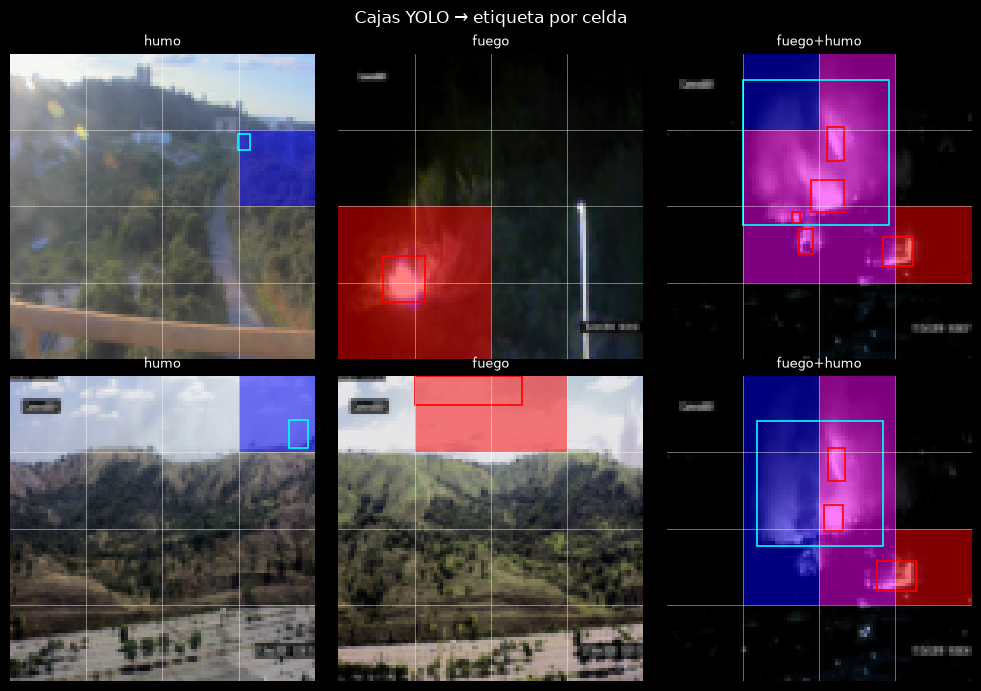

In [ ]:
from matplotlib.patches import Rectangle


def pintar_grilla(ax, imagen, grilla, titulo, cajas=()):
    '''Imagen con la grilla encima: rojo = fuego, azul = humo. La opacidad de cada celda es
    su valor (etiqueta 0/1 o probabilidad). `cajas` (K, 5) dibuja además las cajas YOLO.'''
    alto, ancho = IMG_SIZE
    n = grilla.shape[0]
    ax.imshow(np.asarray(imagen).astype("uint8"))
    color = np.zeros((n, n, 4))
    color[..., 0] = grilla[..., 0]                  # rojo: fuego
    color[..., 2] = grilla[..., 1]                  # azul: humo
    color[..., 3] = 0.5 * grilla.max(axis=-1)       # transparente donde no hay nada
    ax.imshow(color, extent=(-0.5, ancho - 0.5, alto - 0.5, -0.5), interpolation="nearest")
    for k in range(1, n):
        ax.axhline(k * alto / n - 0.5, color="white", lw=0.5, alpha=0.6)
        ax.axvline(k * ancho / n - 0.5, color="white", lw=0.5, alpha=0.6)
    for canal, x0, y0, x1, y1 in cajas:
        if canal >= 0:                              # canal -1 = relleno de la tabla
            ax.add_patch(Rectangle((x0 * ancho - 0.5, y0 * alto - 0.5),
                                   (x1 - x0) * ancho, (y1 - y0) * alto, fill=False, lw=1.2,
                                   color="red" if canal == 0 else "cyan"))
    ax.set_xlim(-0.5, ancho - 0.5)
    ax.set_ylim(alto - 0.5, -0.5)
    ax.set_title(titulo, fontsize=9)
    ax.axis("off")


# Dos imágenes de train por combinación con cajas: humo, fuego, fuego+humo.
ejemplos = [np.flatnonzero((SPLITS == "train") & (COMBO == c))[k]
            for k in range(2) for c in (1, 2, 3)]
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for ax, i in zip(axes.ravel(), ejemplos):
    pintar_grilla(ax, leer_imagen(ARCHIVOS[i]), GRILLAS[i], COMBOS[COMBO[i]], CAJAS[i])
plt.suptitle("Cajas YOLO → etiqueta por celda")
plt.tight_layout()
plt.show()

## 3. Pipeline de datos

Mismas decisiones que en el notebook 4 (96×96 nativo del OV2640, RGB, partición oficial
del banco). Lo que cambia es **dónde va el aumento**.

En el notebook 4 el aumento era parte del modelo de entrenamiento (`modelo_train =
aumento + modelo_base`), porque la etiqueta de imagen no depende de la geometría: una foto
con fuego rotada sigue teniendo fuego. La etiqueta por celda sí depende: rotar, trasladar
o hacer zoom mueve el fuego a otras celdas. Imagen y máscara tienen que recibir **la misma
transformación**, y el modelo sólo ve la imagen. Por eso el aumento pasa a `tf.data`,
antes de calcular las etiquetas:

```
imagen, cajas ─(cache)─> imagen, máscara 96×96×2 ─(lote)─> aumento de las dos ─> imagen, {salida, grilla}
```

Las capas de aumento de Keras 3 aceptan un diccionario `{"images", "segmentation_masks"}`.
Cada capa sortea **una** transformación y la aplica a las dos claves: la geometría
(espejo, rotación, traslación, zoom) mueve la máscara igual que la imagen, con vecino más
cercano para que siga siendo 0/1, y la fotometría (contraste, brillo) sólo toca la imagen.

La excepción es `RandomErasing`, que deja la máscara intacta. Si el parche tapa entero un
fuego chico, la etiqueta seguiría diciendo `fuego` sobre una imagen sin llama (en el
notebook 4 pasaba lo mismo). `BorradoConMascara` lo corrige: apaga la máscara bajo el
parche, y como las etiquetas salen de la máscara, lo tapado deja de contar.

Dos efectos secundarios: el aumento corre ahora en CPU dentro de `tf.data` (en el 4 corría
en la GPU, como parte del modelo), así que cada época puede tardar un poco más; y ya no
hacen falta dos modelos, porque el que se entrena es el mismo que se exporta.

In [ ]:
from dfire import particion

BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Partición oficial del banco, desordenada sólo DENTRO de cada split (igual que en el 4).
particiones = particion(SPLITS, SEED)
idx_train, idx_val, idx_test = (particiones[s] for s in ("train", "val", "test"))

for nombre, idx in [("train", idx_train), ("val", idx_val), ("test", idx_test)]:
    reparto = "  ".join(f"{COMBOS[c]} {np.sum(COMBO[idx] == c)}"
                        for c in range(len(COMBOS)))
    print(f"{nombre:<6} {len(idx):>6} imágenes    {reparto}")

train   14122 imágenes    nada 6458  humo 3836  fuego 770  fuego+humo 3058
val      3099 imágenes    nada 1375  humo 845  fuego 174  fuego+humo 705
test     4306 imágenes    nada 2005  humo 1186  fuego 220  fuego+humo 895


In [ ]:
class BorradoConMascara(layers.RandomErasing):
    '''`RandomErasing` que además apaga la máscara bajo el parche.

    La capa original sólo borra la imagen. Acá se reusa la transformación que Keras ya
    sorteó para la imagen (`batch_masks`: dónde está el parche; `apply_erasing`: si esa
    imagen se borra o no), así que el parche de la imagen y el de la máscara coinciden.
    Son claves internas de Keras 3.15 (fijado en `uv.lock`).
    '''

    def transform_segmentation_masks(self, segmentation_masks, transformation, training=True):
        if not training:
            return segmentation_masks
        tapado = self.backend.numpy.logical_and(
            transformation["batch_masks"][..., :1],                 # (B, H, W, 1)
            transformation["apply_erasing"][:, None, None, None],   # (B, 1, 1, 1)
        )
        return self.backend.numpy.where(tapado, 0.0, segmentation_masks)


# Las mismas capas y factores que el notebook 4 (ver allá el porqué de cada una).
CAPAS_AUMENTO = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(1 / 12),      # ±30°
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.10),
    layers.RandomBrightness(0.15),
    BorradoConMascara(factor=0.5, scale=(0.02, 0.15)),
]


def aumento(imagenes, mascaras):
    '''Aumenta un lote de imágenes y sus máscaras con la MISMA transformación.'''
    datos = {"images": imagenes, "segmentation_masks": mascaras}
    for capa in CAPAS_AUMENTO:
        datos = capa(datos, training=True)
    return datos["images"], datos["segmentation_masks"]


def imagenes_y_mascaras(idx, mezclar=False):
    '''Lotes de (imagen float32 0-255, máscara 96×96×2) de las imágenes `idx`.

    Se cachea la imagen decodificada y las cajas (unos bytes por imagen), no la máscara:
    pintarla en cada época cuesta menos que guardarla (~1 GB en float32 sólo en train).
    '''
    ds = tf.data.Dataset.from_tensor_slices((ARCHIVOS[idx], CAJAS[idx]))
    ds = ds.map(lambda r, c: (leer_imagen(r), c), num_parallel_calls=AUTOTUNE).cache()
    if mezclar:
        ds = ds.shuffle(1000, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda x, c: (tf.cast(x, tf.float32), mascara_cajas(c)),
                num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE)


def armar_ds_grilla(idx, aumentar=False):
    '''Lotes de (imagen, {"salida": (2,), "grilla": (GRILLA, GRILLA, 2)}).

    Con `aumentar` mezcla y aumenta ANTES de calcular las etiquetas: las etiquetas son las
    de la imagen aumentada. Sin aumentar, el orden es el de `idx`.
    '''
    ds = imagenes_y_mascaras(idx, mezclar=aumentar)
    if aumentar:
        ds = ds.map(aumento, num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, m: (x, objetivos(m, GRILLA)), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)


train_ds = armar_ds_grilla(idx_train, aumentar=True)
val_ds = armar_ds_grilla(idx_val)
test_ds = armar_ds_grilla(idx_test)
print(f"lotes por época: {len(train_ds)}")

lotes por época: 442


**Verificación visual del aumento.** Es la celda que más importa del pipeline: la grilla
y el contorno amarillo (la máscara de fuego, píxel a píxel) tienen que seguir a la llama
en cada variante. Si quedan corridos respecto del fuego, imagen y máscara se
desalinearon, y todo lo que sigue entrena con etiquetas equivocadas.

W0000 00:00:1790099459.729068  128274 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


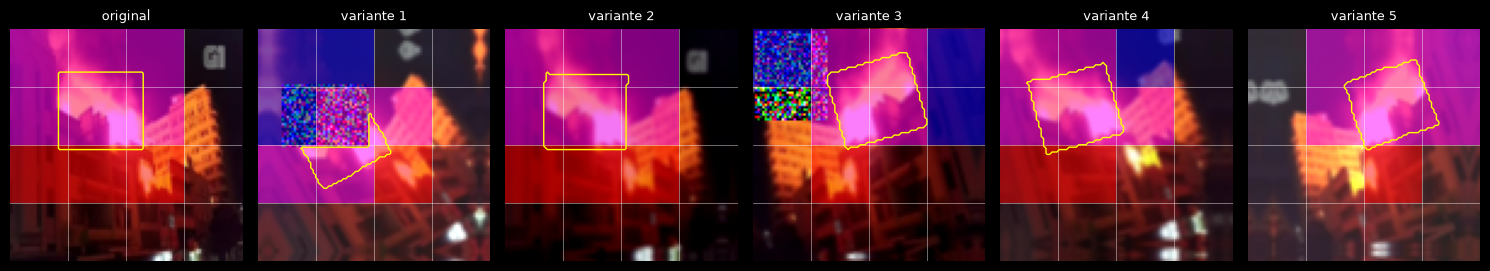

In [ ]:
lote_x, lote_m = next(iter(imagenes_y_mascaras(idx_train)))
con_fuego_lote = np.flatnonzero(lote_m.numpy()[..., 0].max(axis=(1, 2)))
assert len(con_fuego_lote), "el primer lote no tiene fuego: probar con otro"
i = int(con_fuego_lote[0])

N_VARIANTES = 5
xs, ms = aumento(tf.repeat(lote_x[i:i + 1], N_VARIANTES, axis=0),
                 tf.repeat(lote_m[i:i + 1], N_VARIANTES, axis=0))
gs = objetivos(ms, GRILLA)["grilla"].numpy()
ms = ms.numpy()

fig, axes = plt.subplots(1, N_VARIANTES + 1, figsize=(15, 2.9))
pintar_grilla(axes[0], lote_x[i], objetivos(lote_m[i:i + 1], GRILLA)["grilla"][0].numpy(),
              "original")
axes[0].contour(lote_m[i, ..., 0].numpy(), [0.5], colors="yellow", linewidths=1)
for k, ax in enumerate(axes[1:]):
    pintar_grilla(ax, xs[k], gs[k], f"variante {k + 1}")
    if ms[k, ..., 0].max() > 0:     # el zoom o el borrado pueden sacar el fuego del cuadro
        ax.contour(ms[k, ..., 0], [0.5], colors="yellow", linewidths=1)
plt.tight_layout()
plt.show()

## 4. Arquitectura: dos cabezas sobre el mismo backbone

```
96×96×3 → Rescaling → MobileNetV1 α=0.25 ─┬─ conv_pw_5  12×12×64 → MaxPool 3×3 → 4×4×64
                                          │     → Conv 1×1 (32, ReLU6) → Conv 1×1 (2, sigmoide)   grilla 4×4×[fuego, humo]
                                          │
                                          └─ conv_pw_13  3×3×256 → GAP → Dropout(0.4) → Dense(2, sigmoide)
                                                                                                  salida [fuego, humo]
```

- **La cabeza de imagen es idéntica a la del notebook 4.** Por eso sus métricas se pueden
  comparar: lo único distinto es que el backbone además aprende a localizar.
- **Por qué `conv_pw_5` (12×12) y no el mapa final (3×3):** el final es más grueso que la
  grilla y no puede dar 4×4. En `conv_pw_5` (paso 8) cada celda de la grilla junta 3×3
  posiciones del mapa, y cada posición "ve" unos 43 px de la imagen: contexto suficiente
  para un fuego, sin perder la resolución que pide un foco chico. `conv_pw_11` (6×6) no se
  divide en 4.
- **Conv 1×1 = una `Dense` por celda con los mismos pesos en todas.** Es el clasificador
  del notebook 4 aplicado a cada zona del cuadro, no una red nueva.
- **ReLU6** en la capa intermedia, por la misma razón que en MobileNet: acota el rango
  para la cuantización int8.

Costo en el nodo: conv 64→32 (2080 parámetros, 16·64·32 = 32 768 MAC) + conv 32→2
(66 parámetros, 1024 MAC). En total **+2146 parámetros y +34 k MAC**, el 0,45 % de los
7,5 MMAC del backbone. Todas son ops int8 que TFLite Micro ya ejecuta (`CONV_2D`,
`MAX_POOL_2D`, `LOGISTIC`).

Queda **un solo modelo**: sin aumento adentro, el que se entrena es el que se exporta.
Optimizador (`AdamW` + EMA) y entrenamiento en dos etapas, igual que en el notebook 4.

In [ ]:
ALPHA = 0.25                        # factor de ancho de MobileNetV1, igual que en el 4
CAPA_GRILLA = "conv_pw_5_relu"      # 12×12×64 a 96×96 (paso 8)


def construir_modelo(n_clases, n_grilla):
    '''Píxeles 0-255 -> escala fija -> MobileNetV1 -> {salida: (2,), grilla: (n, n, 2)}.'''
    entrada = keras.Input(shape=(*IMG_SIZE, 3), name="entrada")
    # Escala fija a [-1, 1], plegada por el converter (entrada int8: `pixel - 128`).
    x = layers.Rescaling(1 / 127.5, offset=-1, name="rescaling")(entrada)

    mobilenet = keras.applications.MobileNet(
        alpha=ALPHA, include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3),
    )
    # El mismo backbone con dos salidas: el mapa intermedio para la grilla y el final para
    # la imagen. Son las mismas capas y los mismos pesos: corre una sola vez.
    backbone = keras.Model(
        mobilenet.input, [mobilenet.get_layer(CAPA_GRILLA).output, mobilenet.output],
        name="mobilenet",
    )
    # Etapa 1: backbone congelado (se descongela en §5 con lr/10).
    backbone.trainable = False
    mapa, final = backbone(x)

    # Cabeza de imagen: la del notebook 4.
    y = layers.GlobalAveragePooling2D(name="gap")(final)
    y = layers.Dropout(0.4, name="dropout")(y)
    salida = layers.Dense(n_clases, activation="sigmoid", name="salida")(y)

    # Cabeza de grilla: agrupa el mapa en n×n celdas y clasifica cada una.
    paso = mapa.shape[1] // n_grilla
    assert paso * n_grilla == mapa.shape[1], (
        f"una grilla de {n_grilla} no divide el mapa de {mapa.shape[1]}×{mapa.shape[1]}")
    g = layers.MaxPooling2D(paso, name="pool_grilla")(mapa)
    g = layers.Conv2D(32, 1, activation="relu6", name="conv_grilla")(g)
    grilla = layers.Conv2D(n_clases, 1, activation="sigmoid", name="grilla")(g)

    return keras.Model(entrada, {"salida": salida, "grilla": grilla}, name="cnn_fuego_grilla")


modelo = construir_modelo(len(CLASES), GRILLA)
modelo.summary()

/tmp/ipykernel_128274/2066438646.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = keras.applications.MobileNet(


Model: "cnn_fuego_grilla"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ entrada             │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 96, 96, 3) │          0 │ entrada[0][0]     │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenet           │ [(None, 12, 12,   │    218,544 │ rescaling[0][0]   │
│ (Functional)        │ 64), (None, 3, 3, │            │                   │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_grilla         │ (None, 4, 4, 64)  │          0 │ mobilenet[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 256)       │          0 │ mobilenet[0][1]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_grilla         │ (None, 4, 4, 32)  │      2,080 │ pool_grilla[0][0] │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ grilla (Conv2D)     │ (None, 4, 4, 2)   │         66 │ conv_grilla[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ salida (Dense)      │ (None, 2)         │        514 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 221,204 (864.08 KB)

 Trainable params: 2,660 (10.39 KB)

 Non-trainable params: 218,544 (853.69 KB)

## 5. Entrenamiento

Mismas dos etapas que el notebook 4 (cabeza sola con lr = 1e-3, después ajuste fino
completo con lr = 1e-4, recompilando entre las dos), mismos *callbacks* y el mismo
`AdamW` + EMA. Lo nuevo es la pérdida:

$$\mathcal{L} = \mathrm{BCE}(\text{salida}) + \lambda \cdot \mathrm{BCE}_{w}(\text{grilla})$$

- **`BCE(salida)`**: la entropía cruzada binaria del notebook 4, sin cambios.
- **`BCE_w(grilla)`**: la misma pérdida por celda y etiqueta, pero las celdas positivas
  pesan más. Menos del 10 % de las celdas tiene fuego (§2): sin peso, la forma más barata
  de bajar la pérdida es decir "nada" en casi todas. El peso es
  $\sqrt{\text{negativas}/\text{positivas}}$: la proporción completa empuja a la red a
  encender celdas de más, y lo que falte lo compensa el umbral, como en el notebook 4.
- **λ = `PESO_GRILLA`** reparte la atención entre las dos tareas. Con 1 pesan parecido.
  Si la cabeza de imagen empeora respecto del notebook 4, bajarlo.

`EarlyStopping` y `ReduceLROnPlateau` miran `val_loss`, la suma de las dos. Métricas:
`BinaryAccuracy` para la imagen, como antes, y **AUC-PR** para la grilla. La exactitud por
celda no sirve: diciendo "nada" en todas acierta en más del 85 % de las celdas.

In [ ]:
# Peso de las celdas positivas: raíz de negativas/positivas en train, por etiqueta.
PESO_POSITIVAS = np.sqrt((1 - TASA_POSITIVAS) / TASA_POSITIVAS).astype("float32")
PESO_GRILLA = 1.0       # λ: peso de la pérdida de la grilla frente a la de imagen
print("peso de las celdas positivas:",
      {c: round(float(p), 2) for c, p in zip(CLASES, PESO_POSITIVAS)})


def perdida_grilla(y, p):
    '''Entropía cruzada binaria por celda y etiqueta; las positivas pesan PESO_POSITIVAS.'''
    return keras.ops.binary_crossentropy(y, p) * (1.0 + (PESO_POSITIVAS - 1.0) * y)


def compilar(lr):
    # ema_overwrite_frequency = pasos de una época: sin esto EarlyStopping pisa el
    # promedio al restaurar los mejores pesos (ver notebook 4, §4).
    modelo.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=lr, use_ema=True, ema_momentum=0.99,
            ema_overwrite_frequency=len(train_ds),
        ),
        loss={"salida": "binary_crossentropy", "grilla": perdida_grilla},
        loss_weights={"salida": 1.0, "grilla": PESO_GRILLA},
        metrics={"salida": [keras.metrics.BinaryAccuracy(name="accuracy")],
                 "grilla": [keras.metrics.AUC(curve="PR", name="auc_pr")]},
    )

peso de las celdas positivas: {'fuego': 3.68, 'humo': 1.93}


In [ ]:
EPOCAS_CABEZA = 15      # etapa 1: sólo las cabezas, backbone congelado
EPOCAS_FINO = 120       # etapa 2: ajuste fino de todo con lr/10 (topes: decide EarlyStopping)


def entrenar(epocas, etiqueta):
    print(f"\n--- {etiqueta} ---")
    return modelo.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epocas,
        verbose=2,          # una línea por época
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=8, restore_best_weights=True, verbose=1
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1
            ),
        ],
    ).history


compilar(1e-3)
h1 = entrenar(EPOCAS_CABEZA, f"etapa 1: cabezas solas, lr=1e-3, hasta {EPOCAS_CABEZA} épocas")

# Recompilar es obligatorio para que el cambio de `trainable` entre en el grafo.
modelo.get_layer("mobilenet").trainable = True
compilar(1e-4)
h2 = entrenar(EPOCAS_FINO, f"etapa 2: ajuste fino completo, lr=1e-4, hasta {EPOCAS_FINO} épocas")

historia = {k: h1[k] + h2[k] for k in h1 if k in h2}
CORTE_ETAPAS = len(h1["loss"])
EPOCAS_REALES = len(historia["loss"])
print(f"\n{EPOCAS_REALES} épocas en total ({CORTE_ETAPAS} de cabeza + "
      f"{EPOCAS_REALES - CORTE_ETAPAS} de ajuste fino)")


--- etapa 1: cabezas solas, lr=1e-3, hasta 15 épocas ---
Epoch 1/15


/home/gabi/Documentos/FaCENA/proyecto_final/Desarrollo/Pruebas/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790099469.719192  129020 service.cc:153] XLA service 0x7fd9b0074a80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790099469.719213  129020 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1050, Compute Capability 6.1 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.8.0)
I0000 00:00:1790099469.836503  129020 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790099470.964389  129020 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_o

442/442 - 90s - 203ms/step - grilla_auc_pr: 0.2796 - grilla_loss: 0.6560 - loss: 1.3842 - salida_accuracy: 0.6440 - salida_loss: 0.7277 - val_grilla_auc_pr: 0.4210 - val_grilla_loss: 0.5704 - val_loss: 1.0834 - val_salida_accuracy: 0.7456 - val_salida_loss: 0.5131 - learning_rate: 0.0010
Epoch 2/15
442/442 - 33s - 74ms/step - grilla_auc_pr: 0.4054 - grilla_loss: 0.5723 - loss: 1.1434 - salida_accuracy: 0.7011 - salida_loss: 0.5710 - val_grilla_auc_pr: 0.4654 - val_grilla_loss: 0.5405 - val_loss: 1.0207 - val_salida_accuracy: 0.7661 - val_salida_loss: 0.4804 - learning_rate: 0.0010
Epoch 3/15
442/442 - 27s - 62ms/step - grilla_auc_pr: 0.4273 - grilla_loss: 0.5575 - loss: 1.0968 - salida_accuracy: 0.7195 - salida_loss: 0.5389 - val_grilla_auc_pr: 0.4799 - val_grilla_loss: 0.5312 - val_loss: 1.0022 - val_salida_accuracy: 0.7753 - val_salida_loss: 0.4712 - learning_rate: 0.0010
Epoch 4/15
442/442 - 28s - 63ms/step - grilla_auc_pr: 0.4368 - grilla_loss: 0.5522 - loss: 1.0831 - salida_accura

I0000 00:00:1790099994.659906  129018 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_98600__.191
I0000 00:00:1790100066.365097  129017 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_98600__.191


442/442 - 118s - 268ms/step - grilla_auc_pr: 0.4618 - grilla_loss: 0.5347 - loss: 1.0330 - salida_accuracy: 0.7477 - salida_loss: 0.4992 - val_grilla_auc_pr: 0.5169 - val_grilla_loss: 0.5091 - val_loss: 0.9172 - val_salida_accuracy: 0.8057 - val_salida_loss: 0.4083 - learning_rate: 1.0000e-04
Epoch 2/120
442/442 - 43s - 97ms/step - grilla_auc_pr: 0.4765 - grilla_loss: 0.5241 - loss: 0.9691 - salida_accuracy: 0.7832 - salida_loss: 0.4457 - val_grilla_auc_pr: 0.5283 - val_grilla_loss: 0.5001 - val_loss: 0.8744 - val_salida_accuracy: 0.8246 - val_salida_loss: 0.3746 - learning_rate: 1.0000e-04
Epoch 3/120
442/442 - 31s - 69ms/step - grilla_auc_pr: 0.4900 - grilla_loss: 0.5146 - loss: 0.9331 - salida_accuracy: 0.7997 - salida_loss: 0.4183 - val_grilla_auc_pr: 0.5384 - val_grilla_loss: 0.4928 - val_loss: 0.8464 - val_salida_accuracy: 0.8377 - val_salida_loss: 0.3538 - learning_rate: 1.0000e-04
Epoch 4/120
442/442 - 30s - 67ms/step - grilla_auc_pr: 0.4964 - grilla_loss: 0.5091 - loss: 0.9033

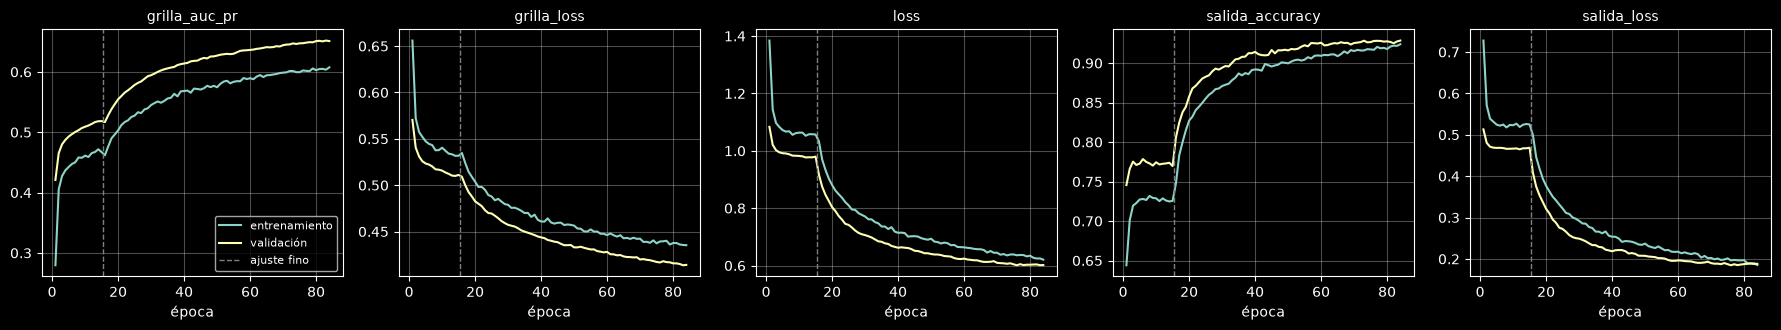

In [ ]:
# Una curva por cada métrica que Keras registró con su versión de validación
# (pérdida total, pérdida de cada cabeza, exactitud de imagen, AUC-PR de grilla).
curvas = [k for k in historia if not k.startswith("val_") and f"val_{k}" in historia]
epocas = range(1, EPOCAS_REALES + 1)

fig, axes = plt.subplots(1, len(curvas), figsize=(3.6 * len(curvas), 3.4))
for ax, k in zip(np.atleast_1d(axes), curvas):
    ax.plot(epocas, historia[k], label="entrenamiento")
    ax.plot(epocas, historia["val_" + k], label="validación")
    ax.axvline(CORTE_ETAPAS + 0.5, color="gray", ls="--", lw=1, label="ajuste fino")
    ax.set_title(k, fontsize=10)
    ax.set_xlabel("época")
    ax.grid(alpha=0.3)
np.atleast_1d(axes)[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Evaluación sobre el conjunto de prueba

Tres lecturas del mismo modelo:

1. **Cabeza de imagen**: el mismo informe del notebook 4, comparable número a número.
   Responde si la supervisión por celda mejoró al clasificador.
2. **Imagen según la grilla**: fuego si alguna celda tiene fuego. Es la alerta que daría
   un nodo que sólo manda la grilla.
3. **La grilla en sí**: por celda, y si la celda más probable cae donde está el fuego.

`test_ds` se armó sin mezclar: las predicciones siguen el orden de `idx_test`, y las
etiquetas verdaderas se leen de `ETIQUETAS` y `GRILLAS`. El umbral de 0,5 es provisorio,
como en el notebook 4.

In [ ]:
pred = modelo.predict(test_ds, verbose=0)
y_prob = pred["salida"]                     # (N, 2): P(fuego), P(humo) de la imagen
g_prob = pred["grilla"]                     # (N, GRILLA, GRILLA, 2): por celda
yg_prob = g_prob.max(axis=(1, 2))           # la imagen según la grilla: su celda máxima

UMBRAL = 0.5
y_true = ETIQUETAS[idx_test]
g_true = GRILLAS[idx_test]
y_pred = (y_prob >= UMBRAL).astype(np.uint8)
yg_pred = (yg_prob >= UMBRAL).astype(np.uint8)
print(f"{len(y_true)} imágenes evaluadas")

4306 imágenes evaluadas


In [ ]:
from sklearn.metrics import classification_report


def informe(y_t, y_p):
    '''Métricas por etiqueta y por combinación, como en el notebook 4 (sin la fila
    `samples avg`, que en las imágenes `nada` no mide nada).'''
    r = classification_report(y_t, y_p, target_names=CLASES, digits=3, zero_division=0)
    print("\n".join(l for l in r.splitlines() if not l.lstrip().startswith("samples")) + "\n")
    print(classification_report(combo(y_t), combo(y_p), labels=range(len(COMBOS)),
                                target_names=COMBOS, digits=3, zero_division=0))


print("=== 1. cabeza de imagen (comparar con §6 del notebook 4) ===")
informe(y_true, y_pred)
print("=== 2. imagen según la grilla (máximo de las celdas) ===")
informe(y_true, yg_pred)

=== 1. cabeza de imagen (comparar con §6 del notebook 4) ===
              precision    recall  f1-score   support

       fuego      0.928     0.874     0.900      1115
        humo      0.893     0.910     0.902      2081

   micro avg      0.905     0.898     0.901      3196
   macro avg      0.911     0.892     0.901      3196
weighted avg      0.905     0.898     0.901      3196

              precision    recall  f1-score   support

        nada      0.922     0.904     0.913      2005
        humo      0.787     0.855     0.819      1186
       fuego      0.691     0.691     0.691       220
  fuego+humo      0.881     0.818     0.848       895

    accuracy                          0.862      4306
   macro avg      0.820     0.817     0.818      4306
weighted avg      0.864     0.862     0.862      4306

=== 2. imagen según la grilla (máximo de las celdas) ===
              precision    recall  f1-score   support

       fuego      0.688     0.871     0.769      1115
        hum

### 6bis. Sin gemelos

Como en el notebook 4: el 22,9 % de las imágenes de prueba tiene un gemelo perceptual en
entrenamiento. La métrica que vale es la del subconjunto **sin** gemelos.

In [ ]:
from dfire import sin_gemelo

LIMPIO = sin_gemelo(ARCHIVOS[idx_train], ARCHIVOS[idx_test])
print(f"prueba: {len(LIMPIO)} imágenes, {np.sum(~LIMPIO)} con gemelo en entrenamiento "
      f"({100 * np.mean(~LIMPIO):.1f} %), {np.sum(LIMPIO)} limpias\n")
print("=== 1. cabeza de imagen, SIN gemelos ===")
informe(y_true[LIMPIO], y_pred[LIMPIO])
print("=== 2. imagen según la grilla, SIN gemelos ===")
informe(y_true[LIMPIO], yg_pred[LIMPIO])

prueba: 4306 imágenes, 986 con gemelo en entrenamiento (22.9 %), 3320 limpias

=== 1. cabeza de imagen, SIN gemelos ===
              precision    recall  f1-score   support

       fuego      0.922     0.867     0.894       996
        humo      0.897     0.911     0.904      1756

   micro avg      0.906     0.895     0.901      2752
   macro avg      0.910     0.889     0.899      2752
weighted avg      0.906     0.895     0.900      2752

              precision    recall  f1-score   support

        nada      0.907     0.893     0.900      1394
        humo      0.772     0.839     0.804       930
       fuego      0.659     0.635     0.647       170
  fuego+humo      0.875     0.818     0.846       826

    accuracy                          0.846      3320
   macro avg      0.803     0.796     0.799      3320
weighted avg      0.848     0.846     0.847      3320

=== 2. imagen según la grilla, SIN gemelos ===
              precision    recall  f1-score   support

       fuego    

### 6ter. La grilla

- **Por celda**: cada una de las 16 celdas de cada imagen de prueba cuenta como un
  ejemplo. El *recall* dice qué parte de las celdas con fuego se encendió; la precisión,
  qué parte de las encendidas tenía fuego. Recordar que las celdas de las esquinas de una
  caja pueden estar marcadas sin llama (§2), así que la precisión por celda es pesimista.
- **¿Apunta al lugar correcto?** En las imágenes que tienen la etiqueta, ¿la celda más
  probable de la red es una celda marcada? No depende de ningún umbral. Se compara contra
  el azar, que es la fracción de celdas marcadas en esas imágenes: una red que no
  localiza no puede superarlo.

In [ ]:
print("=== por celda (umbral provisorio 0,5) ===")
r = classification_report(g_true.reshape(-1, 2), (g_prob >= UMBRAL).reshape(-1, 2).astype(np.uint8),
                          target_names=CLASES, digits=3, zero_division=0)
print("\n".join(l for l in r.splitlines() if not l.lstrip().startswith("samples")) + "\n")


def apunta(sub, titulo):
    print(f"=== celda más probable dentro de la etiqueta: {titulo} ===")
    for c, nombre in enumerate(CLASES):
        con = sub[y_true[sub, c] == 1]
        verdad = g_true[con, :, :, c].reshape(len(con), -1)
        mejor = g_prob[con, :, :, c].reshape(len(con), -1).argmax(axis=1)
        acierto = verdad[np.arange(len(con)), mejor].mean()
        print(f"{nombre:<6} {acierto:6.1%}   (azar {verdad.mean():5.1%})   {len(con)} imágenes")
    print()


apunta(np.arange(len(y_true)), "prueba completa")
apunta(np.flatnonzero(LIMPIO), "sin gemelos")

=== por celda (umbral provisorio 0,5) ===
              precision    recall  f1-score   support

       fuego      0.578     0.739     0.649      4484
        humo      0.628     0.508     0.562     14191

   micro avg      0.612     0.564     0.587     18675
   macro avg      0.603     0.624     0.605     18675
weighted avg      0.616     0.564     0.583     18675

=== celda más probable dentro de la etiqueta: prueba completa ===
fuego   86.9%   (azar 25.1%)   1115 imágenes
humo    76.0%   (azar 42.6%)   2081 imágenes

=== celda más probable dentro de la etiqueta: sin gemelos ===
fuego   86.0%   (azar 27.0%)   996 imágenes
humo    82.2%   (azar 48.3%)   1756 imágenes



### Fallos de fuego según el tamaño de la llama

La misma tabla del notebook 4, con una columna más. Si las cajas ayudan a ver focos
chicos, la mejora tiene que aparecer en las filas de arriba (< 8 px), comparadas contra
las mismas filas del notebook 4.

In [ ]:
def lado_fuego_px(ruta_img):
    '''Lado equivalente (raíz del área) de la caja de fuego más grande, en px a 96×96.'''
    ruta = Path(ruta_img)
    txt = ruta.parent.parent / "labels" / (ruta.stem + ".txt")
    cajas = (l.split() for l in txt.read_text().splitlines() if l.split())
    areas = [float(w) * float(h) for c, _, _, w, h in cajas if c == "1"]
    return np.sqrt(max(areas, default=0.0)) * IMG_SIZE[0]


con_fuego = np.flatnonzero(y_true[:, 0] == 1)
lado = np.array([lado_fuego_px(ARCHIVOS[idx_test][i]) for i in con_fuego])
vio_imagen = y_pred[con_fuego, 0] == 1
vio_grilla = yg_pred[con_fuego, 0] == 1
alerta = y_pred[con_fuego].any(axis=1)      # fuego o humo: la alerta sale igual

print(f"{len(con_fuego)} imágenes de prueba con fuego, umbral provisorio 0,5\n")
print(f"{'lado de la caja':<17}{'imágenes':>9}{'fuego imagen':>14}{'fuego grilla':>14}"
      f"{'con alerta':>12}")
for lo, hi in [(0, 5), (5, 8), (8, 16), (16, 32), (32, np.inf)]:
    m = (lado >= lo) & (lado < hi)
    rango = f"{lo}–{hi:.0f} px" if np.isfinite(hi) else f"≥ {lo} px"
    print(f"{rango:<17}{m.sum():>9}{vio_imagen[m].mean():>14.1%}{vio_grilla[m].mean():>14.1%}"
          f"{alerta[m].mean():>12.1%}")

1115 imágenes de prueba con fuego, umbral provisorio 0,5

lado de la caja   imágenes  fuego imagen  fuego grilla  con alerta
0–5 px                 179         60.3%         57.5%       87.7%
5–8 px                 178         90.4%         86.0%       97.2%
8–16 px                348         92.5%         92.5%       98.9%
16–32 px               270         94.4%         95.9%       98.5%
≥ 32 px                140         92.1%         95.7%       97.9%


## 7. Lo que ve la red, celda por celda

Arriba, la etiqueta (celdas marcadas y cajas YOLO); abajo, la grilla que predice la red.
La opacidad de cada celda es la probabilidad: una celda casi transparente es una
probabilidad baja. Es el equivalente del Grad-CAM del notebook 4, pero es la salida
misma de la red, no una reconstrucción a partir de gradientes.

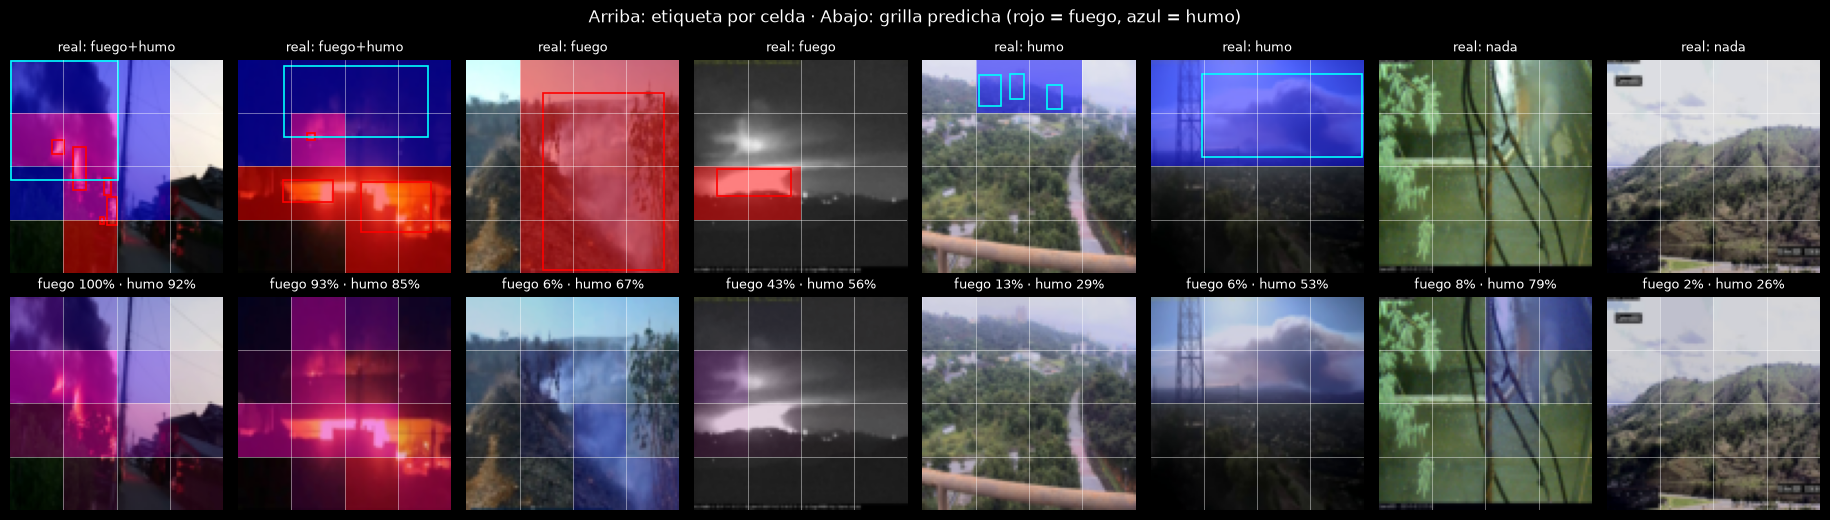

In [ ]:
# Dos imágenes de prueba por combinación: fuego+humo, fuego, humo, nada.
muestras = [i for c in (3, 2, 1, 0) for i in np.flatnonzero(combo(y_true) == c)[:2]]

fig, axes = plt.subplots(2, len(muestras), figsize=(2.3 * len(muestras), 5.4))
for col, i in enumerate(muestras):
    imagen = leer_imagen(ARCHIVOS[idx_test][i])
    pintar_grilla(axes[0, col], imagen, g_true[i], f"real: {COMBOS[combo(y_true[i])]}",
                  CAJAS[idx_test][i])
    pintar_grilla(axes[1, col], imagen, g_prob[i],
                  f"fuego {yg_prob[i, 0]:.0%} · humo {yg_prob[i, 1]:.0%}")
plt.suptitle("Arriba: etiqueta por celda · Abajo: grilla predicha (rojo = fuego, azul = humo)")
plt.tight_layout()
plt.show()

## 8. Entregable: el modelo entrenado

| Archivo | Qué es |
|---|---|
| `salidas/modelos/grilla4x4_fuego_epochs_*_image_size_96x96.keras` | modelo de dos salidas, float32 |

El prefijo **no** es `cnn_fuego_`: `5_cuantizacion.ipynb` toma el `cnn_fuego_*.keras` más
reciente y espera una sola salida de 2 valores, así que con ese nombre agarraría este
modelo por error. Para cargarlo usar `keras.models.load_model(ruta, compile=False)`: la
pérdida de la grilla (`perdida_grilla`) es una función de este notebook, y Keras no la
encuentra fuera de él.

In [ ]:
ruta_modelos = SALIDAS / "modelos"
ruta_modelos.mkdir(parents=True, exist_ok=True)
ruta_keras = ruta_modelos / (f"grilla{GRILLA}x{GRILLA}_fuego_epochs_{EPOCAS_REALES}"
                             f"_image_size_{IMG_SIZE[0]}x{IMG_SIZE[1]}.keras")
modelo.save(ruta_keras)
print(f"{ruta_keras}  ({ruta_keras.stat().st_size / 1024:.0f} kB)")

../salidas/modelos/grilla4x4_fuego_epochs_84_image_size_96x96.keras  (3821 kB)


## 9. Qué mirar y cómo seguir

**Para decidir entre el notebook 4 y este**, comparar sobre la prueba **sin gemelos**:

- *Recall* de fuego y la fila `fuego+humo` de la cabeza de imagen (§6bis) contra las
  mismas del notebook 4. Si mejoran, la supervisión por celda ayuda al clasificador aunque
  la grilla no se use en el nodo.
- Las filas < 8 px de la tabla de tamaños. Es donde las cajas deberían notarse más.
- "¿Apunta al lugar correcto?" (§6ter), bien por encima del azar. Si queda cerca, la
  grilla no localiza y no vale la pena mandarla.

**Perillas**, de la más a la menos probable de tocar:

| Perilla | Dónde | Efecto |
|---|---|---|
| `PESO_GRILLA` (λ) | §5 | más alto: más localización, a costa de la cabeza de imagen |
| `PESO_POSITIVAS` | §5 | más alto: más celdas encendidas (más *recall*, menos precisión por celda) |
| `GRILLA` | §2 | 6 o 12 con el mismo `CAPA_GRILLA`: más resolución, menos contexto por celda |
| `CAPA_GRILLA` | §4 | un mapa más profundo da más contexto (humo) y menos resolución |

**Para llevar la grilla al nodo** falta adaptar `5_cuantizacion.ipynb` a dos salidas: el
`.tflite` va a tener dos tensores de salida, cada uno con su escala int8, y un umbral por
celda que elegir en validación. Del lado del firmware, empaquetar 16 celdas × 2 bits = 4
bytes por imagen en la trama LoRa.